In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvbchokshi/linear-regression-2a/train.csv
/kaggle/input/datasets/dhruvbchokshi/linear-regression-2a/test.csv


In [2]:
import math
import numpy as np
import pandas as pd
import plotly.express as px
import pickle
import matplotlib.pyplot as plt

In [3]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/dhruvbchokshi/linear-regression-2a')

['train.csv', 'test.csv']

In [4]:
df = pd.read_csv('/kaggle/input/datasets/dhruvbchokshi/linear-regression-2a/train.csv')

In [5]:
df.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [6]:
px.scatter(df, x='x', y='y', title="Training Data")

In [7]:
df.describe()

,x,y
count,700.000000,699.000000
mean,54.985939,49.939869
std,134.681703,29.109217
min,0.000000,-3.839981
25%,25.000000,24.929968
50%,49.000000,48.973020
75%,75.000000,74.929911
max,3530.157369,108.871618


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize both columns
df[['x', 'y']] = scaler.fit_transform(df[['x', 'y']])

**Standardize the data**
Standardization is the process of transforming data so that each feature has a mean of 0 and a standard deviation of 1. This ensures that all features are on the same scale, which helps the model learn more effectively.


**Why Use Standardization in Machine Learning?**
In machine learning, features can have very different ranges (for example, one feature may range from 0–1000 while another ranges from 0–1). This can cause models to give more importance to features with larger values. Standardization removes this imbalance by scaling all features to a similar range.
It also helps gradient descent converge faster and prevents instability during training.


**How to Standardize Data**
Data is standardized using the formula:
z=(x-𝜇)/𝜎
where:
𝜇=μ is the mean of the feature
𝜎=σ is the standard deviation
Each value is transformed by subtracting the mean and dividing by the standard deviation, resulting in a distribution with mean 0 and standard deviation 1.

In [9]:
df.describe()

,x,y
count,7.000000e+02,6.990000e+02
mean,-4.567775e-17,-1.016513e-17
std,1.000715e+00,1.000716e+00
min,-4.085578e-01,-1.848843e+00
25%,-2.228022e-01,-8.597899e-01
50%,-4.447686e-02,-3.323831e-02
75%,1.487089e-01,8.591072e-01
max,2.582130e+01,2.025954e+00


In [10]:
X_train = df['x'].values.reshape(-1,1)
y_train = df['y'].values

**Reshaping data for the correct shape for the model**
Machine learning models expect input data in a specific format, typically a 2D array of shape (number of samples × number of features). Reshaping ensures that the data matches this required structure so that mathematical operations like matrix multiplication can be performed correctly.


**Why can’t we make the model without reshaping?**
Without reshaping, the data may be in an incorrect format (such as a 1D array), which can lead to dimension mismatch errors during operations like dot product. Since linear regression relies on matrix multiplication, incorrect shapes will either cause errors or produce incorrect results.
Reshaping ensures compatibility between input data and model parameters, enabling proper computation.
Linear regression uses vectorized operations, and these require strict alignment of dimensions. Reshaping guarantees that inputs follow the (m, n) format, where m is number of samples and n is number of features.


In [11]:
print(X_train.shape)
print(y_train.shape)

(700, 1)
(700,)


In [12]:
class LinearRegression:

    def __init__(self, lr=0.0001):
        self.lr = lr

    def initialize_parameters(self):
        self.m = 0  # slope
        self.b = 0  # intercept

    def forward(self, X):
        return self.m * X + self.b

    def compute_cost(self, y, y_pred):
        n = len(y)
        cost = (1/n) * np.sum((y - y_pred) ** 2)
        return cost

    def backward(self, X, y, y_pred):
        n = len(y)
        dm = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        self.m = self.m - self.lr * dm
        self.b = self.b - self.lr * db

    def fit(self, X, y, iterations, plot_cost=True):
        self.initialize_parameters()
        costs = []

        for i in range(iterations):
            y_pred = self.forward(X)
            cost = self.compute_cost(y, y_pred)
            self.backward(X, y, y_pred)

            costs.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

        if plot_cost:
            plt.plot(costs)
            plt.title("Cost vs Iterations")
            plt.xlabel("Iterations")
            plt.ylabel("Cost")
            plt.show()

    def predict(self, X):
        return self.forward(X)

    def save_model(self, filename="model.pkl"):
        with open(filename, "wb") as f:
            pickle.dump((self.m, self.b), f)

    @classmethod
    def load_model(cls, filename):
        with open(filename, "rb") as f:
            m, b = pickle.load(f)

        model = cls()
        model.m = m
        model.b = b
        return model

In [13]:
# Clean data
df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Standardize
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df[['x']]).flatten()
y = df['y'].values

Iteration 0, Cost: 1.0
Iteration 100, Cost: 0.6731196282812861
Iteration 200, Cost: 0.45409290771194244
Iteration 300, Cost: 0.30733370014275085
Iteration 400, Cost: 0.20899745628012956
Iteration 500, Cost: 0.14310709739106456
Iteration 600, Cost: 0.09895715608768198
Iteration 700, Cost: 0.06937441667092034
Iteration 800, Cost: 0.04955245438593351
Iteration 900, Cost: 0.036270716569427874


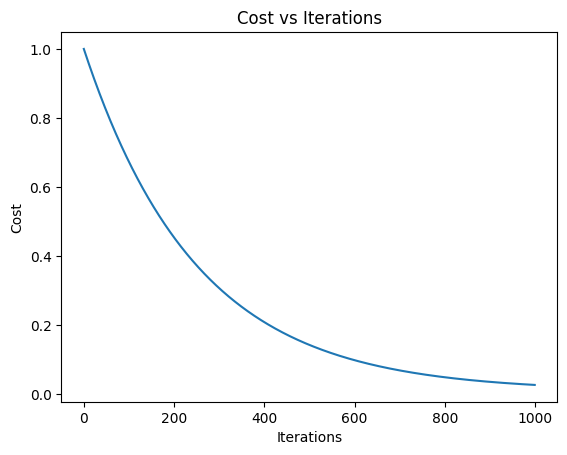

In [14]:
lr = LinearRegression(lr=0.001)
lr.fit(X, y, iterations=1000)

In [15]:
lr.save_model('model.pkl')

In [16]:
class RegressionMetrics:

    @staticmethod
    def mean_squared_error(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(RegressionMetrics.mean_squared_error(y_true, y_pred))

    @staticmethod
    def r_squared(y_true, y_pred):
        # SSR = sum of squared residuals
        # SST = total sum of squares
        ssr = np.sum((y_true - y_pred) ** 2)
        sst = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ssr / sst)

### 1. Mean Squared Error (MSE)

**Formula:**
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_{\text{true}_i} - y_{\text{pred}_i})^2
$$

**Description:**
Mean Squared Error (MSE) measures the average of the squared differences between the actual values and the predicted values. It penalizes larger errors more heavily due to the squaring term.

**Interpretation:**
A lower MSE indicates better model performance. An MSE of 0 means perfect predictions, while higher values indicate larger prediction errors.

### 2. Root Mean Squared Error (RMSE)

**Formula:**
$$
\text{RMSE} = \sqrt{\text{MSE}}
$$

**Description:**
Root Mean Squared Error (RMSE) is the square root of MSE. It represents the average prediction error in the same units as the target variable, making it more interpretable than MSE.

**Interpretation:**
A lower RMSE indicates a better fit of the model. Since it is in the same units as the output, it directly shows how far predictions are from actual values on average.


### 3. R-squared ($R^2$)

**Formula:**
$$
R^2 = 1 - \frac{\text{SSR}}{\text{SST}}
$$

**Description:**
R-squared (coefficient of determination) measures the proportion of variance in the dependent variable that is explained by the independent variables in the model.

**Interpretation:**
R² ranges from 0 to 1. A value closer to 1 indicates that the model explains most of the variability in the data, while a value closer to 0 indicates poor explanatory power.


In [17]:
y_pred = lr.predict(X)

mse_value = RegressionMetrics.mean_squared_error(y, y_pred)
rmse_value = RegressionMetrics.root_mean_squared_error(y, y_pred)
r_squared_value = RegressionMetrics.r_squared(y, y_pred)

print(f"Mean Squared Error (MSE): {mse_value:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_value:.4f}")
print(f"R-squared: {r_squared_value:.4f}")

Mean Squared Error (MSE): 0.0274
Root Mean Squared Error (RMSE): 0.1654
R-squared: 0.9726


Iteration 0, Cost: 1.0
Iteration 100, Cost: 0.6731953967576682
Iteration 200, Cost: 0.45421944497819466
Iteration 300, Cost: 0.3074942551185828
Iteration 400, Cost: 0.20918080487716137
Iteration 500, Cost: 0.14330571889076388
Iteration 600, Cost: 0.09916601122046033
Iteration 700, Cost: 0.06959012886605777
Iteration 800, Cost: 0.04977276116677049
Iteration 900, Cost: 0.036494101959826955
MSE: 24.0115469839742
RMSE: 4.900157852964964


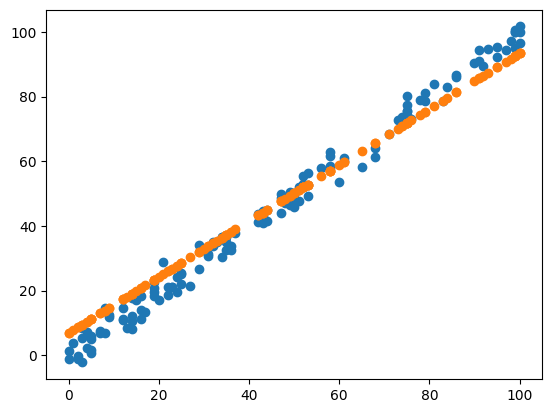

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/input/datasets/dhruvbchokshi/linear-regression-2a/train.csv')

df['x'] = pd.to_numeric(df['x'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')

df = df.dropna()

X = df['x'].values
y = df['y'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

mean_x, std_x = X_tr.mean(), X_tr.std()
mean_y, std_y = y_tr.mean(), y_tr.std()

if std_x == 0:
    std_x = 1
if std_y == 0:
    std_y = 1

X_train2 = (X_tr - mean_x) / std_x
X_test2  = (X_te - mean_x) / std_x
y_train2 = (y_tr - mean_y) / std_y

class LinearRegression:
    def __init__(self, lr=0.001):
        self.lr = lr

    def initialize_parameters(self):
        self.m = 0
        self.b = 0

    def forward(self, X):
        return self.m * X + self.b

    def compute_cost(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def backward(self, X, y, y_pred):
        n = len(y)
        dm = (-2/n) * np.sum(X * (y - y_pred))
        db = (-2/n) * np.sum(y - y_pred)

        self.m -= self.lr * dm
        self.b -= self.lr * db

    def fit(self, X, y, iterations=1000, plot_cost=True):
        self.initialize_parameters()
        costs = []

        for i in range(iterations):
            y_pred = self.forward(X)
            cost = self.compute_cost(y, y_pred)
            self.backward(X, y, y_pred)

            costs.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {cost}")

        if plot_cost:
            plt.plot(costs)
            plt.title("Cost vs Iterations")
            plt.show()

    def predict(self, X):
        return self.forward(X)

model = LinearRegression(lr=0.001)
model.fit(X_train2, y_train2, iterations=1000, plot_cost=False)

y_pred2 = model.predict(X_test2) * std_y + mean_y

mse = np.mean((y_te - y_pred2) ** 2)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)

plt.scatter(X_te, y_te)
plt.scatter(X_te, y_pred2)
plt.show()